# Signal denoising

The module contains several signal noise filtering functions. All of them are based on the discrete wavelet transform, referred to as [DWT](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html), or techniques that utilize various combinations of them. Each of them has its own advantages and disadvantages when filtering low-noise and high-noise signals. The following functions are currently implemented:

- denoise using base [DWT](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html)
- usinng [Stationary Wavelet Transform](https://pywavelets.readthedocs.io/en/latest/ref/swt-stationary-wavelet-transform.html)
- using [Packet Wavelet Transform](https://pywavelets.readthedocs.io/en/latest/ref/wavelet-packets.html)
- using [Multiresolution Wavelet Transform](https://pywavelets.readthedocs.io/en/latest/ref/mra.html)

Let's take a "clean" signal, add Gaussian noise and compare the results.

In [1]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
from IPython.display import display, Markdown, HTML
import sys
from pathlib import Path
# shim for working with local copy
if str(Path.cwd().parent.parent.name) == 'scaleo':
    parent_dir = str(Path.cwd().parent.parent.parent)
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

from scaleo import CWT

In [2]:
methods_list = ['DWT', 'WPT', 'SWT', 'MRA']
def draw_comparision(noisy_vector, clean_signal, denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA):
    s_alpha, lw = .85, .7
    plt.figure(figsize=(16, 7))
    plt.plot(noisy_vector, label='Noisy Input Vector', alpha=0.45, linewidth=3., color='gray')
    plt.plot(clean_signal, label='Original Clean Signal', color='black', linestyle='--')
    plt.plot(denoised_WPT, label='Denoised WPT', color='green', linewidth=lw, alpha=s_alpha)
    plt.plot(denoised_DWT, label='Denoised DWT', color='red', linewidth=lw, alpha=s_alpha)
    plt.plot(denoised_SWT, label='Denoised SWT', color='blue', linewidth=lw, alpha=s_alpha)
    plt.plot(denoised_MRA, label='Denoised MRA', color='darkorange', linewidth=lw, alpha=s_alpha)
    plt.title(f'Vector Denoising')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Define Evaluation Metric Functions
def calculate_mse(clean, processed):
    """Mean Squared Error"""
    return np.mean((clean - processed) ** 2)

def calculate_rmse(clean, processed):
    """Root Mean Squared Error"""
    return np.sqrt(calculate_mse(clean, processed))

def calculate_snr(clean, processed):
    """Signal-to-Noise Ratio (dB)"""
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean((clean - processed) ** 2)
    return 10 * np.log10(signal_power / noise_power)

def calculate_psnr(clean, processed):
    """Peak Signal-to-Noise Ratio (dB)"""
    max_val = np.max(clean) - np.min(clean)
    mse = calculate_mse(clean, processed)
    return 20 * np.log10(max_val / np.sqrt(mse))

def signal_compare_table(clean_signal, noisy_vector, denoised_signal, method:str) -> pd.DataFrame:
    """
    Signal-to-Noise Ratio (SNR): Measures the power of the signal relative to the noise. A higher SNR indicates a cleaner signal.
    Mean Squared Error (MSE): Calculates the average squared difference between the denoised signal and the original signal. Lower values indicate better accuracy.
    Peak Signal-to-Noise Ratio (PSNR): Commonly used in image and audio processing, it measures the maximum possible power of a signal against the corrupting noise.
    Root Mean Squared Error (RMSE): The square root of the MSE, providing an error metric in the same units as the original signal.
    """
    mse_before = calculate_mse(clean_signal, noisy_vector)
    snr_before = calculate_snr(clean_signal, noisy_vector)
    # After denoising (Denoised vs Clean)
    mse_after = calculate_mse(clean_signal, denoised_signal)
    rmse_after = calculate_rmse(clean_signal, denoised_signal)
    snr_after = calculate_snr(clean_signal, denoised_signal)
    psnr_after = calculate_psnr(clean_signal, denoised_signal)
    # index_arr = ['MSE (Lower is better)', 'RMSE', 'SNR (Higher is better)', 'PSNR']
    index_arr = [method]
    top_cols = [item for item in  ['MSE (Lower is better)', 'RMSE', 'SNR (Higher is better)', 'PSNR'] for _ in range(2)]
    columns = pd.MultiIndex.from_tuples(list(zip(top_cols, ['Before', 'After'] * len(methods_list) )))
    val_arr = [[
        f"{mse_before:.4f}", f"{mse_after:.4f}",
        ' ', f"{rmse_after:.4f}",
        f"{snr_before:.2f} dB", f"{snr_after:.2f} dB",
        ' ', f"{psnr_after:.2f} dB"
    ]]
    df = pd.DataFrame( data=val_arr, index=index_arr, columns=columns, dtype='string')
    return df

def results_compare_table(noisy_vector, clean_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA):
    res_df = None
    for s in list(zip(methods_list, [denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA])):
        df = signal_compare_table(clean_signal, noisy_vector, s[1], s[0])
        res_df = df if res_df is None else pd.concat([res_df, df], axis=0, ignore_index=False)
    return res_df

In [3]:
# Generate a clean sine wave vector and inject random noise
fs = 1                  # Sampling frequency (Hz)
duration = 300          # time period in sec
np.random.seed(42)
t = np.linspace(0, duration, int(duration * fs), endpoint=False)
p1 = 20; f1 = 1./p1;
p2 = 60; f2 = 1./p2;
clean_signal = np.cos( (2*np.pi*f1) * t) + 0.6*np.cos( (2*np.pi*f2) * t)
noisy_vector = clean_signal + np.random.normal(0, 0.1, len(t))  #  Gausian noise
# noisy_vector = clean_signal + np.random.uniform(-0.1, 0.1, len(t))  #  Uniform Noise
cwt = CWT(noisy_vector, fs, t, 'cmor1.0-1.5', xlabel='Time (sec.)')

wavelet_name = 'db4'

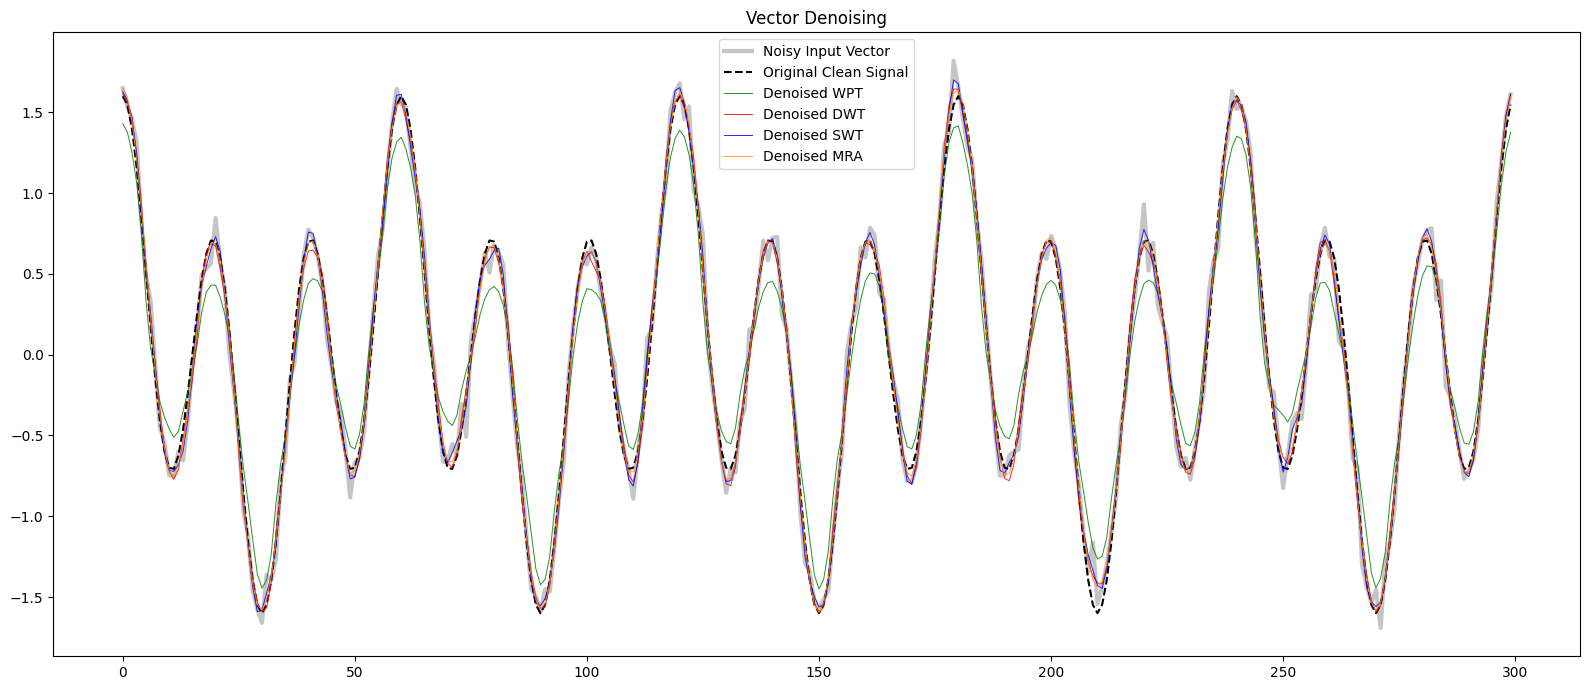

--- Quantitative Evaluation Results ---

In [4]:
denoised_DWT = cwt.denoise_DWT(wavelet_name, 2)
denoised_WPT = cwt.denoise_WPT(wavelet_name, maxlevel=2)
denoised_SWT = cwt.denoise_SWT(wavelet_name, level=2)
denoised_MRA = cwt.denoise_MRA(wavelet_name, level=2)
draw_comparision(noisy_vector, clean_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA)

res_df = results_compare_table(noisy_vector, clean_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA)
display(Markdown(f"--- Quantitative Evaluation Results ---"))
display(HTML(
    res_df.style.set_table_styles(
        [
            {'selector': 'th.col1, th.col3, th.col5, th.col7, td.col1, td.col3, td.col5, td.col7',
             'props': [('border-right', '1px solid black')]},
            {'selector': 'td.col0',
             'props': [('border-left', '1px solid black')]},
            {'selector': 'thead tr:first-child th',
             'props': [('color', 'darkblue')]},
        ]
    ).to_html()
))

For the case of a low-noise signal, DWT produces a result that is closest to the original noise-free signal. SWT has similar results but quite less accurate. WPT restores the frequency value well, but loses signal power. MRA do the same job better and did not loss signal power.

Let's do the same test for high noise

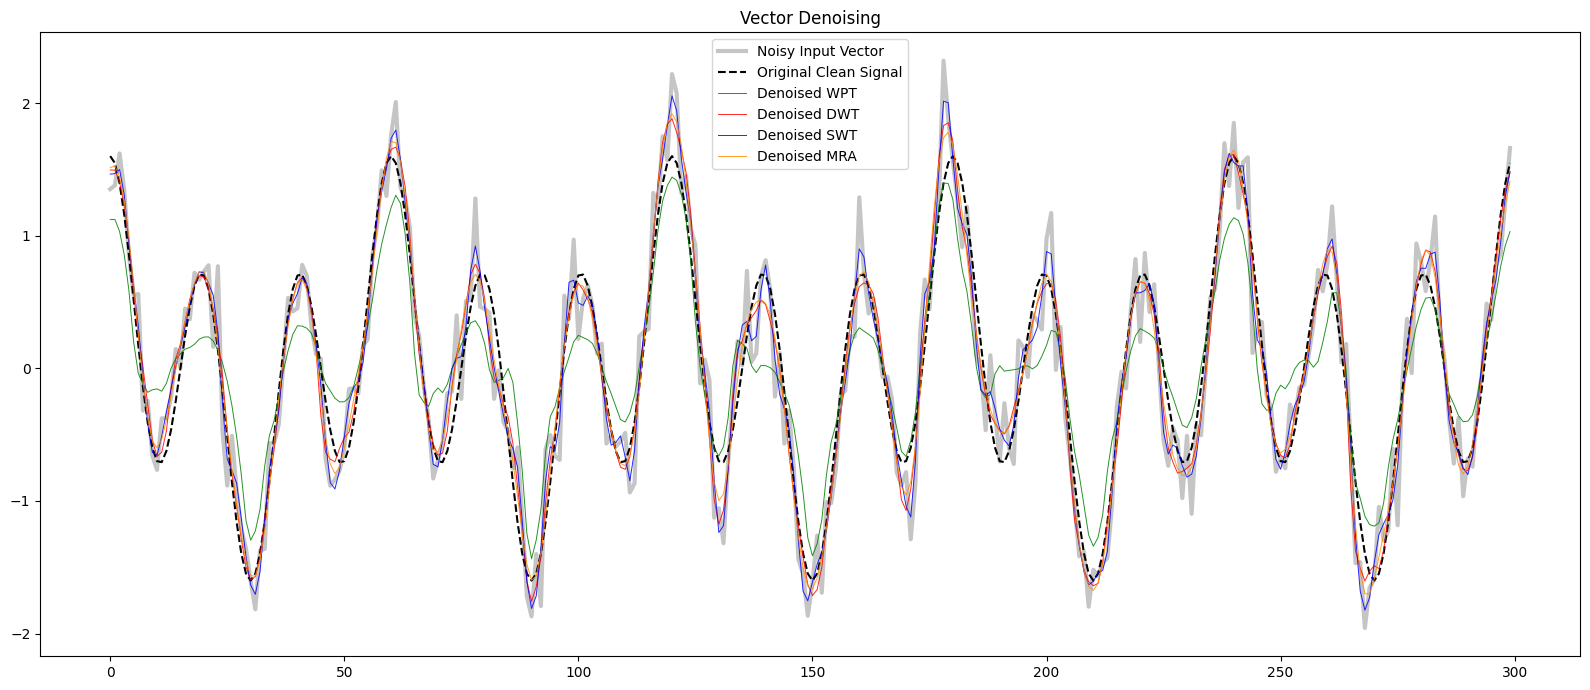

--- Quantitative Evaluation Results ---

In [5]:
noisy_vector = clean_signal + np.random.normal(0, 0.3, len(t))  #  Gausian noise
cwt = CWT(noisy_vector, fs, t, 'cmor1.0-1.5', xlabel='Time (sec.)')

denoised_DWT = cwt.denoise_DWT(wavelet_name, 2)
denoised_WPT = cwt.denoise_WPT(wavelet_name, maxlevel=2)
denoised_SWT = cwt.denoise_SWT(wavelet_name, level=2)
denoised_MRA = cwt.denoise_MRA(wavelet_name, level=2)
draw_comparision(noisy_vector, clean_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA)

res_df = results_compare_table(noisy_vector, clean_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA)
display(Markdown(f"--- Quantitative Evaluation Results ---"))
display(HTML(
    res_df.style.set_table_styles(
        [
            {'selector': 'th.col1, th.col3, th.col5, th.col7, td.col1, td.col3, td.col5, td.col7',
             'props': [('border-right', '1px solid black')]},
            {'selector': 'td.col0',
             'props': [('border-left', '1px solid black')]},
            {'selector': 'thead tr:first-child th',
             'props': [('color', 'darkblue')]},
        ]
    ).to_html()
))

On a highly noisy signal, MRA produces a stable result that is closer to the original signal. SWT still has a good frequency response, but is more susceptible to distortion. DWT and SWT tend to add unnecessary amplitude.

Now let's look on sawtooth signal. A sawtooth wave is a non-sinusoidal waveform named for its resemblance to the teeth of a saw. It features a slow, linear ramp in one direction followed by an abrupt, near-instantaneous vertical drop or rise.
Let's emulate '_ideal_' violine sound and add slight noise.

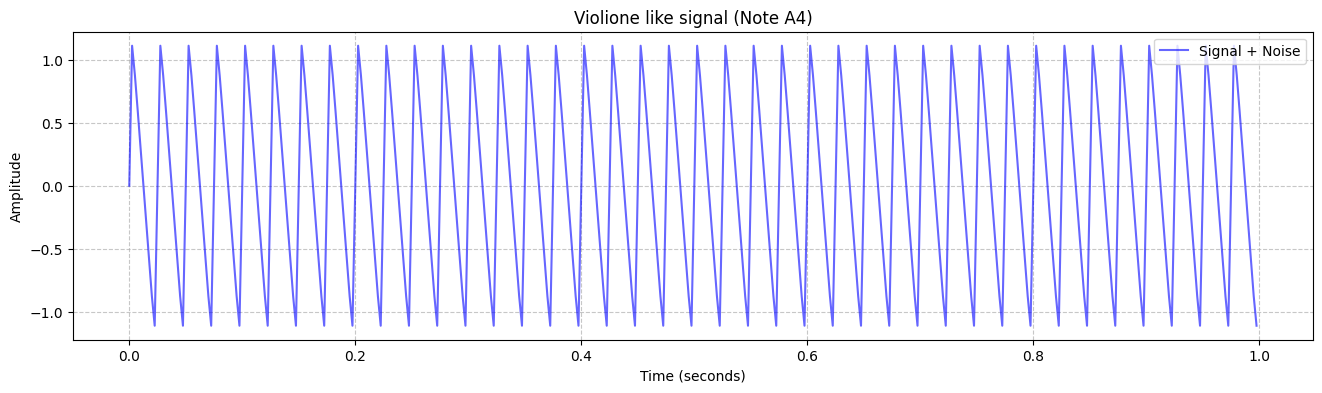

In [6]:
sample_rate = 400  # Hz
duration = 1.0       # Seconds
frequency = 440.0    # Hz (Note A4)

t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# Create harmonics (sawtooth-like decay, common for bowed strings)
violin_signal = np.zeros_like(t)
for n in range(1, 10):
    # Amplitude drops by 1/n for natural/sawtooth timbre
    amplitude = 1.0 / n
    harmonic_freq = frequency * n
    # Calculate sinusoid for this harmonic and add to the signal
    violin_signal += amplitude * np.sin(2 * np.pi * harmonic_freq * t)
# Add Vibrato and Tremolo (Bow Characteristics)
# vibrato = 0.005 * np.sin(2 * np.pi * 6 * t)  # 6 Hz pitch modulation
# violin_signal = np.sin(2 * np.pi * freq * t + vibrato) * np.exp(-0.2 * t) # Exponential decay
# Normalize to 16-bit integer bounds
# violin_signal = violin_signal / np.max(np.abs(violin_signal))
# violin_signal = (violin_signal * 32767).astype(np.int16)

plt.figure(figsize=(16, 4))
plt.plot(t, violin_signal, label='Signal + Noise', color='blue', alpha=0.6)
# plt.plot(t, sine_wave, label='Clean Sine Wave (10 Hz)', color='red', linewidth=2)
plt.title('Violione like signal (Note A4)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

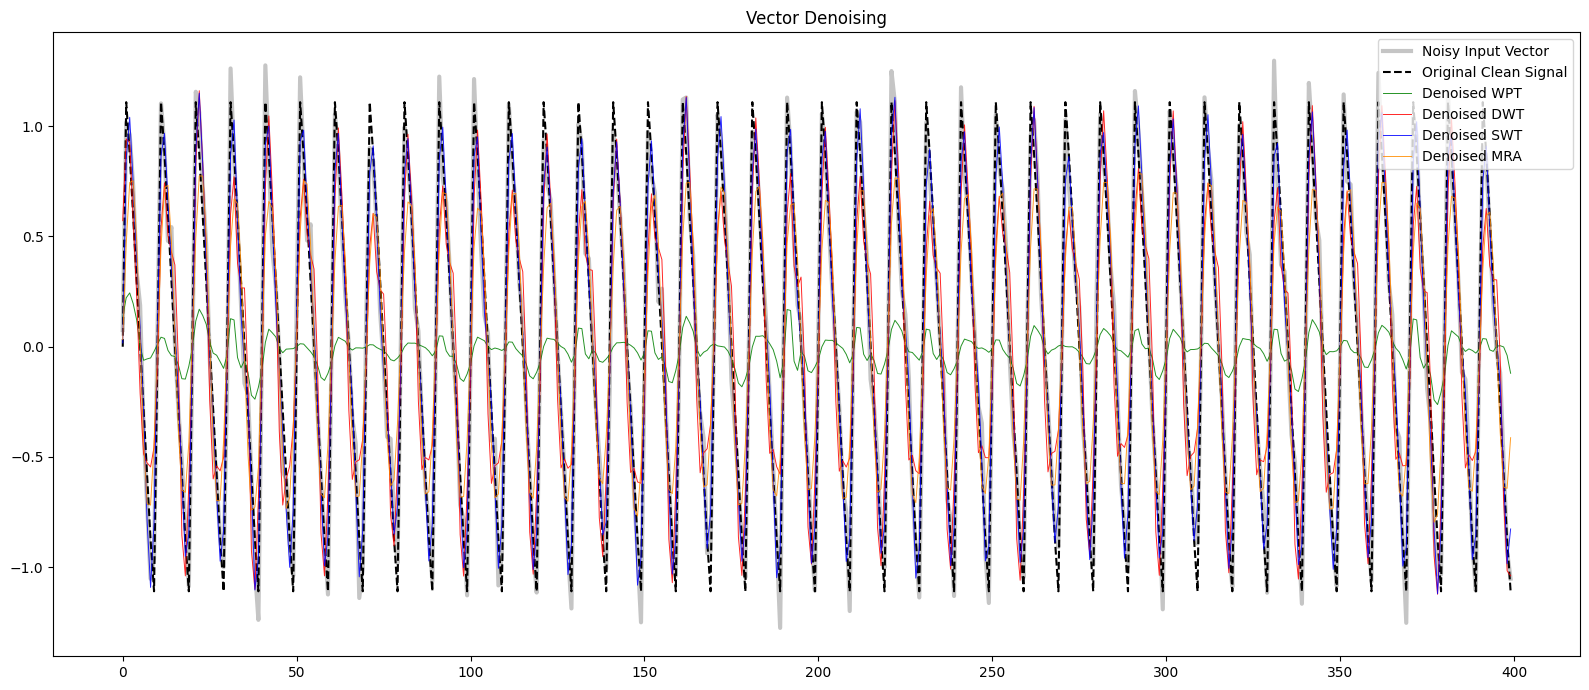

--- Quantitative Evaluation Results ---

In [7]:
noisy_vector = violin_signal + np.random.normal(0, 0.1, len(t))  #  Gausian noise
cwt = CWT(noisy_vector, sample_rate, t, 'cmor1.0-1.5')
denoised_DWT = cwt.denoise_DWT(wavelet_name, 2)
denoised_WPT = cwt.denoise_WPT(wavelet_name, maxlevel=2)
denoised_SWT = cwt.denoise_SWT(wavelet_name, level=2)
denoised_MRA = cwt.denoise_MRA(wavelet_name, level=2)
draw_comparision(noisy_vector, violin_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA)

res_df = results_compare_table(noisy_vector, violin_signal,  denoised_DWT, denoised_WPT, denoised_SWT, denoised_MRA)
display(Markdown(f"--- Quantitative Evaluation Results ---"))
display(HTML(
    res_df.style.set_table_styles(
        [
            {'selector': 'th.col1, th.col3, th.col5, th.col7, td.col1, td.col3, td.col5, td.col7',
             'props': [('border-right', '1px solid black')]},
            {'selector': 'td.col0',
             'props': [('border-left', '1px solid black')]},
            {'selector': 'thead tr:first-child th',
             'props': [('color', 'darkblue')]},
        ]
    ).to_html()
))

WPT failed to produce a reliable result. SWT and DWT returned the signal closest to the original.